#### Autor: Rainiero Mendoza de Jesus ***6/4/2026***

In [4]:
# Import the libraries

import csv
from pathlib import Path as Path
import matplotlib.pyplot as plt
from datetime import datetime

In [5]:
# We extract the data from the csv file

path = Path('./data/barahona.csv')
lines = path.read_text(encoding='utf-8').splitlines()
reader = csv.reader(lines)
headers_row = next(reader)

In [6]:
# We explore the fields that our csv file has

for index,x in enumerate(headers_row):
    print(index, x)

0 STATION
1 NAME
2 LATITUDE
3 LONGITUDE
4 ELEVATION
5 DATE
6 PRCP
7 PRCP_ATTRIBUTES
8 TAVG
9 TAVG_ATTRIBUTES
10 TMAX
11 TMAX_ATTRIBUTES
12 TMIN
13 TMIN_ATTRIBUTES


In [7]:
# We extract the columns we want

date = headers_row.index('DATE')
tavg = headers_row.index('TAVG')
tmax = headers_row.index('TMAX')
tmin = headers_row.index('TMIN')
station = headers_row.index('STATION')

Let's go through the file taking into account that we only care about the data between 2000 and 2020 and for this study we only care about the data from MARIA MONTEZ INTERNATIONAL, which is located in Barahona. And we create a list structure that contains dictionaries that correspond to each year with its data.

In [8]:
data = []

for i in reader:

    date_current = datetime.strptime(i[date], '%Y-%m-%d')
    year_current = int(date_current.strftime('%Y'))
    
    station_current = i[station]
    tavg_value = i[tavg]
    tmax_value = i[tmax]
    tmin_value = i[tmin]

    if station_current != 'DRM00078482':
        break

    if data:

        last_dict = data[-1]

        if year_current == last_dict['Year']:

            if tavg_value and tavg_value != 'NaN':
                last_dict['ANUAL TAVG LIST'].append(float(tavg_value))

            if tmax_value and tmax_value != 'NaN':
                last_dict['ANUAL TMAX LIST'].append(float(tmax_value))

            if tmin_value and tmin_value != 'NaN':
                last_dict['ANUAL TMIN LIST'].append(float(tmin_value))


        else:

            new_dict = {
                'Year': year_current,
                'ANUAL TAVG LIST': [],
                'ANUAL TMAX LIST': [],
                'ANUAL TMIN LIST': []
            }

            if tavg_value and tavg_value != 'NaN':
                new_dict['ANUAL TAVG LIST'].append(float(tavg_value))

            if tmax_value and tmax_value != 'NaN':
                new_dict['ANUAL TMAX LIST'].append(float(tmax_value))

            if tmin_value and tmin_value != 'NaN':
                new_dict['ANUAL TMIN LIST'].append(float(tmin_value))

            data.append(new_dict)


    else:

        new_dict = {
            'Year': year_current,
            'ANUAL TAVG LIST': [],
            'ANUAL TMAX LIST': [],
            'ANUAL TMIN LIST': []
        }

        if tavg_value and tavg_value != 'NaN':
            new_dict['ANUAL TAVG LIST'].append(float(tavg_value))

        if tmax_value and tmax_value != 'NaN':
            new_dict['ANUAL TMAX LIST'].append(float(tmax_value))

        if tmin_value and tmin_value != 'NaN':
            new_dict['ANUAL TMIN LIST'].append(float(tmin_value))

        data.append(new_dict)

In [9]:
# We verify the structure we created

print(data)

[{'Year': 2000, 'ANUAL TAVG LIST': [81.0, 77.0, 76.0, 80.0, 83.0, 76.0, 78.0, 78.0, 77.0, 78.0, 76.0, 78.0, 75.0, 72.0, 74.0, 75.0, 73.0, 73.0, 76.0, 79.0, 78.0, 73.0, 74.0, 75.0, 77.0, 76.0, 77.0, 76.0, 76.0, 77.0, 77.0, 77.0, 77.0, 78.0, 79.0, 77.0, 80.0, 77.0, 79.0, 78.0, 78.0, 78.0, 78.0, 79.0, 78.0, 78.0, 77.0, 79.0, 78.0, 76.0, 76.0, 75.0, 76.0, 76.0, 77.0, 77.0, 78.0, 78.0, 78.0, 78.0, 77.0, 78.0, 78.0, 79.0, 78.0, 78.0, 78.0, 79.0, 79.0, 78.0, 76.0, 78.0, 79.0, 77.0, 76.0, 77.0, 77.0, 78.0, 79.0, 80.0, 79.0, 79.0, 79.0, 78.0, 79.0, 78.0, 78.0, 80.0, 80.0, 79.0, 78.0, 79.0, 80.0, 79.0, 80.0, 77.0, 78.0, 78.0, 78.0, 79.0, 78.0, 79.0, 79.0, 80.0, 81.0, 81.0, 81.0, 80.0, 81.0, 81.0, 80.0, 78.0, 80.0, 80.0, 81.0, 82.0, 81.0, 81.0, 82.0, 81.0, 77.0, 78.0, 80.0, 81.0, 80.0, 81.0, 81.0, 81.0, 83.0, 81.0, 80.0, 80.0, 81.0, 81.0, 82.0, 83.0, 81.0, 82.0, 83.0, 83.0, 82.0, 82.0, 83.0, 83.0, 82.0, 82.0, 78.0, 83.0, 82.0, 83.0, 83.0, 83.0, 82.0, 83.0, 84.0, 83.0, 83.0, 83.0, 83.0, 84.0, 84.0

In [10]:
# We create lists where we store the data already processed and ready to graph

years, anual_tmaxs, anual_tmins, anual_tavgs = [], [], [], []

In [11]:
# Once the data is grouped, we perform the desired operations

for i in data:
    year = i['Year']
    years.append(year)

    tmax = i['ANUAL TMAX LIST']
    tmax_len = len(tmax)
    valor_final = sum(tmax)/tmax_len
    anual_tmaxs.append(valor_final)

    tmin = i['ANUAL TMIN LIST']
    tmin_len = len(tmin)
    valor_mins = sum(tmin)/tmin_len
    anual_tmins.append(valor_mins)

    tavg = i['ANUAL TAVG LIST']
    tavg_len = len(tavg)
    valor_tavg = sum(tavg)/tavg_len
    anual_tavgs.append(valor_tavg)

In [12]:
# Exploramos las listas para verificar 

print(years)
print(anual_tmaxs)
print(anual_tmins)
print(anual_tavgs)

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
[88.41228070175438, 88.52121212121212, 87.94626865671641, 88.38461538461539, 87.89084507042253, 88.5373665480427, 89.91605839416059, 90.19928825622776, 89.15151515151516, 89.55015197568389, 90.1182108626198, 89.30745341614907, 89.21016949152542, 90.17454545454545, 89.72668810289389, 90.16825396825396, 90.02605863192183, 89.71381578947368, 89.31481481481481, 89.81672025723472, 90.14429530201342]
[72.10526315789474, 71.94848484848485, 72.44179104477612, 73.8, 73.0, 72.40213523131672, 69.85766423357664, 71.92526690391459, 70.83164983164983, 71.05775075987842, 71.47603833865814, 69.82298136645963, 70.63728813559322, 71.82181818181819, 72.11254019292605, 72.76190476190476, 72.31596091205212, 71.4342105263158, 71.78395061728395, 72.73311897106109, 73.31543624161074]
[80.65254237288136, 82.24712643678161, 82.41359773371104, 82.51754385964912, 82.02287581699346, 82.771

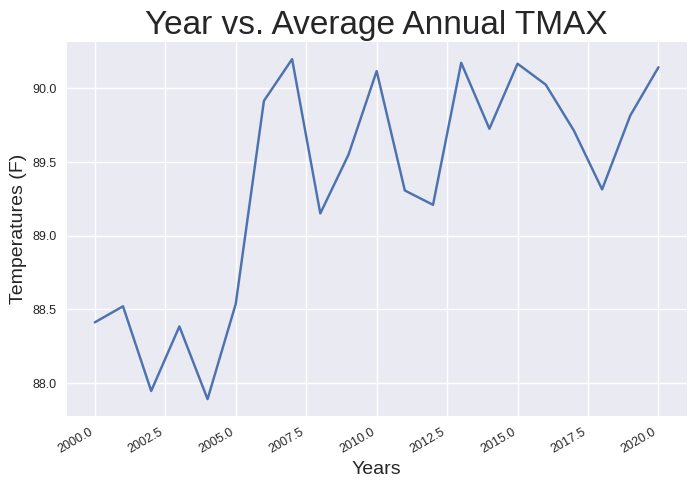

In [13]:
# Make a plots, Year vs. Average Annual TMAX

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMAX"
fig, ax = plt.subplots()
ax.plot(years, anual_tmaxs)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

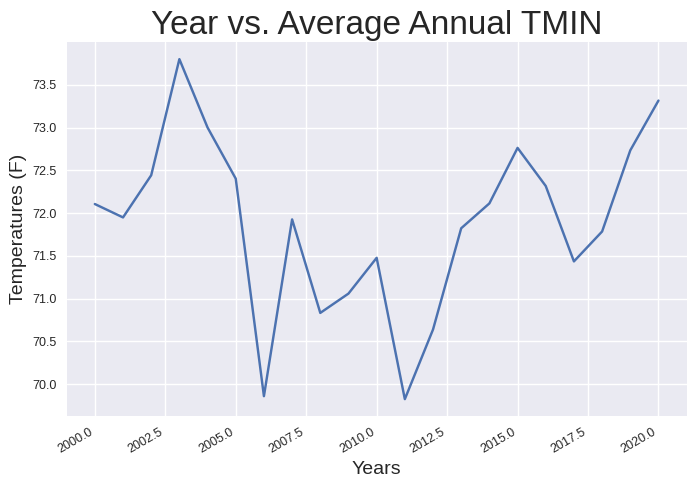

In [14]:
# Make a plot, Year vs. Average Annual TMIN

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMIN"
fig, ax = plt.subplots()
ax.plot(years, anual_tmins)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

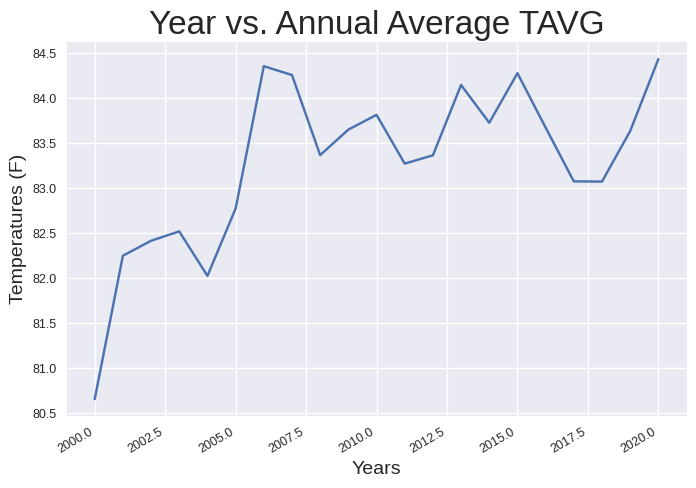

In [15]:
# Make a plot, Year vs. Annual Average TAVG

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs. Annual Average TAVG"
ax.plot(years, anual_tavgs)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

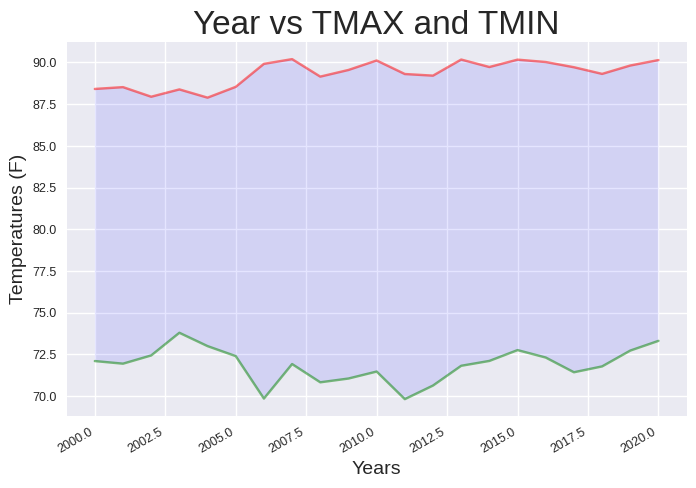

In [16]:
# Make a plot, Year vs TMAX and TMIN

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs TMAX and TMIN"
ax.plot(years, anual_tmaxs, color='red', alpha=0.5)
ax.plot(years, anual_tmins, color='green', alpha=0.5)
ax.fill_between(years, anual_tmaxs, anual_tmins, alpha=0.1, facecolor='blue')

ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()